In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
House_df= pd.read_csv('House_prise_prediction.csv')

In [3]:
House_df.head()

,SquareFeet,Bedrooms,Bathrooms,Age,Price
0,3974,4,1,1,620190
1,1660,5,1,16,337970
2,2094,1,3,12,359550
3,1930,5,1,27,360984
4,1895,5,2,19,361807


In [4]:
House_df.drop(['Bathrooms','Age'] ,axis=1,inplace = True)

In [5]:
House_df.head()

,SquareFeet,Bedrooms,Price
0,3974,4,620190
1,1660,5,337970
2,2094,1,359550
3,1930,5,360984
4,1895,5,361807


In [6]:
House_df.corr()

,SquareFeet,Bedrooms,Price
SquareFeet,1.000000,-0.094508,0.960684
Bedrooms,-0.094508,1.000000,0.073757
Price,0.960684,0.073757,1.000000


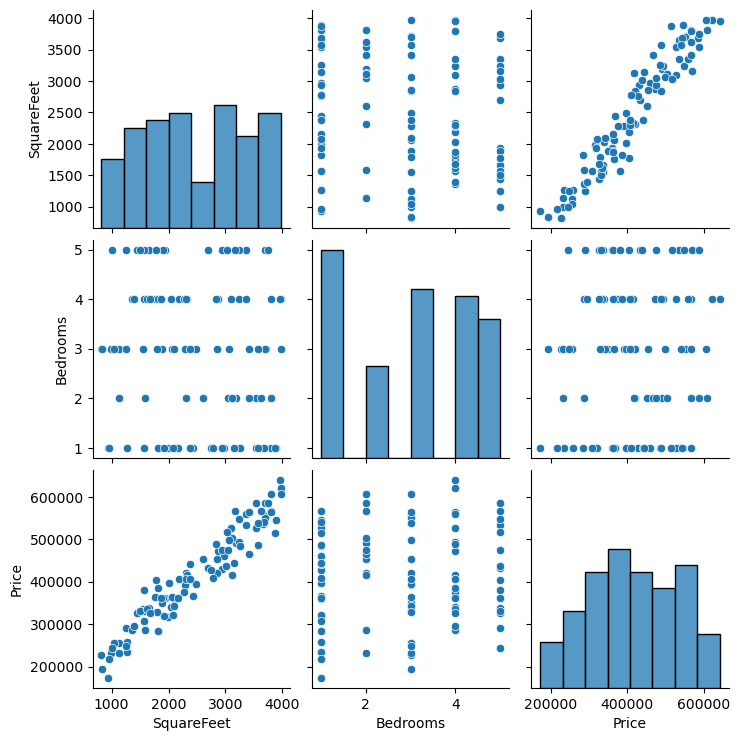

In [7]:
sns.pairplot(House_df)
plt.show()

In [8]:
x = House_df.iloc[:,:-1]
y= House_df.iloc[:,-1]

In [9]:
y

0     620190
1     337970
2     359550
3     360984
4     361807
       ...  
95    362246
96    286126
97    499647
98    308294
99    517681
Name: Price, Length: 100, dtype: int64

In [10]:
x.head()

,SquareFeet,Bedrooms
0,3974,4
1,1660,5
2,2094,1
3,1930,5
4,1895,5


In [11]:
y.shape

(100,)

In [12]:
from sklearn.model_selection import train_test_split


In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [14]:
x_train.head()

,SquareFeet,Bedrooms
15,930,1
40,3534,2
96,1591,2
9,2038,4
72,2385,1


In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

In [17]:
x_train=scaler.fit_transform(x_train)
x_test=scaler.fit_transform(x_test)

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
Regression= LinearRegression()

In [20]:
Regression.fit(x_train,y_train)


LinearRegression()

In [21]:
y_pred = Regression.predict(x_test)

In [22]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [23]:
mae= mean_absolute_error(y_test,y_pred)
mse= mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

In [24]:
from sklearn.metrics import r2_score

In [25]:
score = r2_score(y_test,y_pred)

In [26]:
1-(1-score)*(len(y_test))/(len(y_test)-x_test.shape[1]-1)

0.9312139853537139

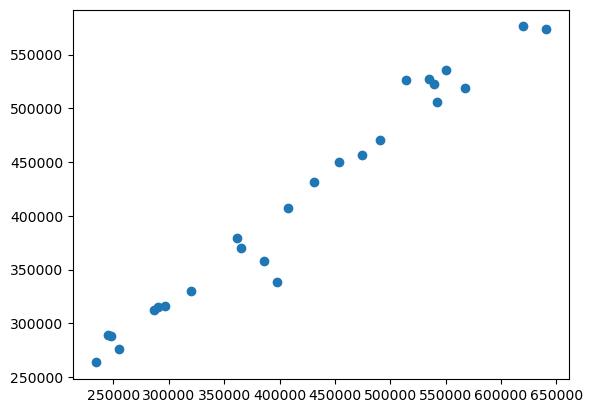

In [27]:
plt.scatter(y_test,y_pred)
plt.show()

In [28]:
Res=y_test-y_pred

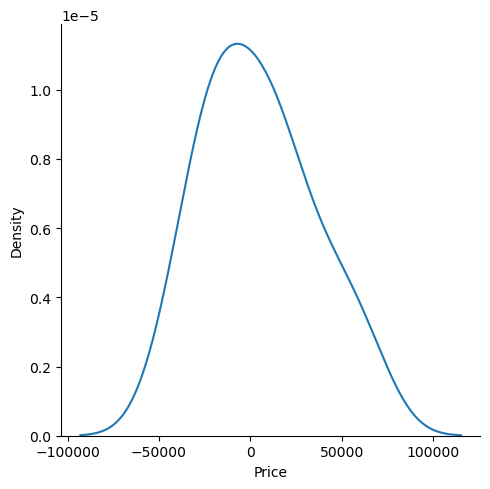

In [29]:
sns.displot(Res,kind='kde')
plt.show()

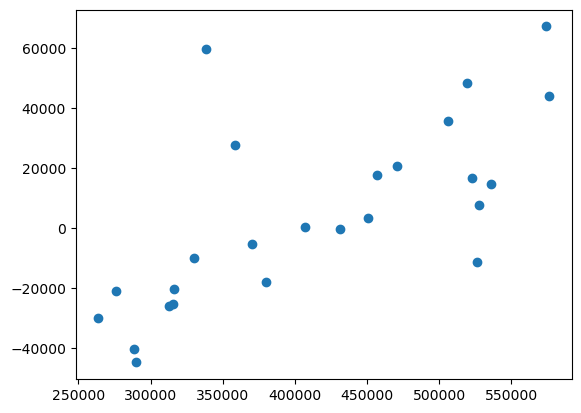

In [30]:
plt.scatter(y_pred,Res)
plt.show()

In [31]:
Regression.coef_

array([103981.79555559,  19203.77701919])

In [32]:
import statsmodels.api as sm

In [33]:
models=sm.OLS(y_train,x_train).fit()

In [34]:
print(models.summary())

                                 OLS Regression Results                                
Dep. Variable:                  Price   R-squared (uncentered):                   0.061
Model:                            OLS   Adj. R-squared (uncentered):              0.035
Method:                 Least Squares   F-statistic:                              2.356
Date:                Sun, 26 Oct 2025   Prob (F-statistic):                       0.102
Time:                        21:07:48   Log-Likelihood:                         -1076.5
No. Observations:                  75   AIC:                                      2157.
Df Residuals:                      73   BIC:                                      2162.
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [35]:
A = input('Enter your house size to predict')
B=  input('Enter your house size to predict')

In [36]:
hous=Regression.predict(scaler.transform([[A,B]]))
house_pre=int(hous)

d:\test\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: could not convert string to float: ''

In [ ]:
print(f' Your house prise should be ${house_pre}')

 Your house prise should be $352712


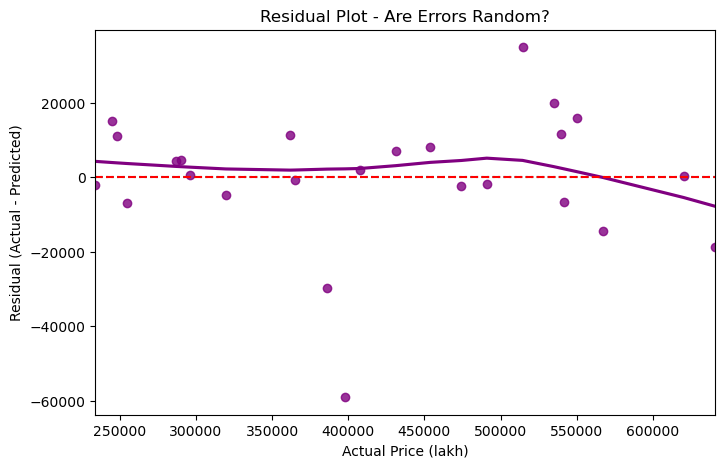

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.residplot(x=y_test, y=y_pred, lowess=True, color="purple")
plt.title("Residual Plot - Are Errors Random?")
plt.xlabel("Actual Price (lakh)")
plt.ylabel("Residual (Actual - Predicted)")
plt.axhline(0, color='red', linestyle='--')
plt.show()